# Series de Tiempo — Temperatura de Guatemala

**Curso:** CC3084 · Data Science · Semestre 02, 2026  
**Periodo del conjunto:** enero de 1950 a junio de 2026.


# Dependencias 

In [39]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import linregress, fligner
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 20)

# Ejercicio 1 
Cargue el archivo con R o con Python y explórelo un poco, ¿Cuáles son los extremos de la temperatura promedio de la tierra? ¿y por capa? ¿Como ha sido la tendencia, ha bajado, subido, se ha mantenido constante alrededor de un valor?

In [40]:
rutas = [
    Path("../data/raw/guatemala_temperatura.csv"),
    Path("data/raw/guatemala_temperatura.csv"),
    Path("01_series_tiempo/data/raw/guatemala_temperatura.csv"),
    Path("guatemala_temperatura.csv"),
    Path("/mnt/data/guatemala_temperatura.csv"),
]

ruta_csv = next((r for r in rutas if r.exists()), None)
if ruta_csv is None:
    raise FileNotFoundError("No se encontró guatemala_temperatura.csv.")

df = (
    pd.read_csv(ruta_csv, parse_dates=["month"])
      .sort_values("month")
      .set_index("month")
      .asfreq("MS")
)

print("Archivo:", ruta_csv)
print("Observaciones:", len(df))
print("Periodo:", df.index.min().strftime("%Y-%m"), "a", df.index.max().strftime("%Y-%m"))
print("Valores faltantes:", int(df.isna().sum().sum()))
print("Fechas duplicadas:", int(df.index.duplicated().sum()))
display(df.head())

Archivo: ..\data\raw\guatemala_temperatura.csv
Observaciones: 918
Periodo: 1950-01 a 2026-06
Valores faltantes: 0
Fechas duplicadas: 0


,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
month,,,,,,,,,
1950-01-01,1950,1,16.685643,20.762313,21.077662,21.661654,21.679957,21.835225,22.458468
1950-02-01,1950,2,15.781276,21.051057,21.518684,22.132758,22.062957,21.964048,22.216061
1950-03-01,1950,3,17.330139,23.197594,23.838886,24.374884,24.100146,23.304599,22.380270
1950-04-01,1950,4,16.499826,23.661600,24.452373,25.059722,24.752231,24.059086,22.955561
1950-05-01,1950,5,19.011177,24.804521,25.501737,26.154377,25.941164,25.252762,23.687375


In [41]:
variables_c = [c for c in df.columns if c.endswith("_c")]

resumen = pd.DataFrame({
    "mínimo_°C": df[variables_c].min(),
    "fecha_mínimo": df[variables_c].idxmin(),
    "máximo_°C": df[variables_c].max(),
    "fecha_máximo": df[variables_c].idxmax(),
    "promedio_°C": df[variables_c].mean(),
})

resumen["rango_°C"] = resumen["máximo_°C"] - resumen["mínimo_°C"]
resumen["fecha_mínimo"] = resumen["fecha_mínimo"].dt.strftime("%Y-%m")
resumen["fecha_máximo"] = resumen["fecha_máximo"].dt.strftime("%Y-%m")

display(resumen.round(2))

,mínimo_°C,fecha_mínimo,máximo_°C,fecha_máximo,promedio_°C,rango_°C
dewpoint_2m_c,14.20,1951-02,21.96,2024-09,18.74,7.76
temperature_2m_c,18.97,1956-01,28.69,2024-05,23.05,9.72
skin_temperature_c,19.15,1956-01,29.74,2024-05,23.44,10.59
soil_temperature_layer_1_c,19.84,1956-01,30.29,2024-05,24.10,10.46
soil_temperature_layer_2_c,19.96,1956-01,29.80,2024-05,24.07,9.84
soil_temperature_layer_3_c,20.49,1956-01,28.35,2024-05,24.01,7.86
soil_temperature_layer_4_c,21.57,1976-02,26.88,2024-06,23.96,5.31


In [42]:
capas_suelo = [c for c in df.columns if c.startswith("soil_temperature_layer")]
resumen_capas = resumen.loc[capas_suelo].copy()

print("Extremos por capa del suelo:")
display(resumen_capas.round(2))

print("Capa con el máximo más alto:", resumen_capas["máximo_°C"].idxmax())
print("Capa con menor variación:", resumen_capas["rango_°C"].idxmin())

Extremos por capa del suelo:


,mínimo_°C,fecha_mínimo,máximo_°C,fecha_máximo,promedio_°C,rango_°C
soil_temperature_layer_1_c,19.84,1956-01,30.29,2024-05,24.10,10.46
soil_temperature_layer_2_c,19.96,1956-01,29.80,2024-05,24.07,9.84
soil_temperature_layer_3_c,20.49,1956-01,28.35,2024-05,24.01,7.86
soil_temperature_layer_4_c,21.57,1976-02,26.88,2024-06,23.96,5.31


Capa con el máximo más alto: soil_temperature_layer_1_c
Capa con menor variación: soil_temperature_layer_4_c


,pendiente_°C_por_década,p_valor,R²
variable,,,
dewpoint_2m_c,0.0833,0.0022,0.0102
temperature_2m_c,0.1708,0.0000,0.0579
skin_temperature_c,0.1676,0.0000,0.0466
soil_temperature_layer_1_c,0.1681,0.0000,0.0472
soil_temperature_layer_2_c,0.1674,0.0000,0.0535
soil_temperature_layer_3_c,0.1661,0.0000,0.0782
soil_temperature_layer_4_c,0.1650,0.0000,0.1425


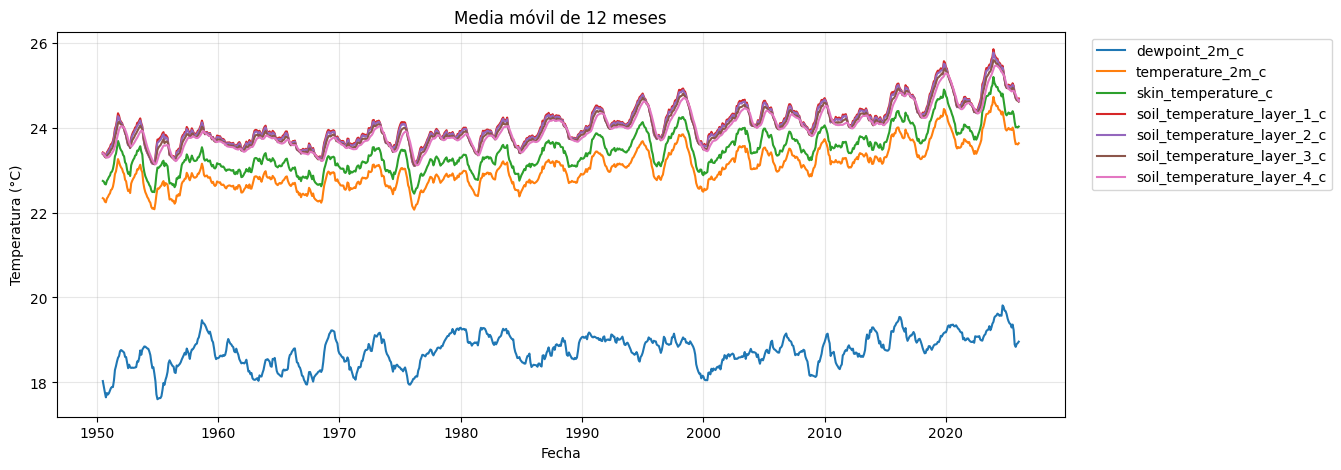

In [43]:
tiempo = np.arange(len(df))
filas = []

for variable in variables_c:
    ajuste = linregress(tiempo, df[variable].values)
    filas.append({
        "variable": variable,
        "pendiente_°C_por_década": ajuste.slope * 120,
        "p_valor": ajuste.pvalue,
        "R²": ajuste.rvalue ** 2,
    })

tendencias = pd.DataFrame(filas).set_index("variable")
display(tendencias.round(4))

media_movil = df[variables_c].rolling(12, center=True).mean()

plt.figure(figsize=(13, 5))
for variable in variables_c:
    plt.plot(media_movil.index, media_movil[variable], label=variable)
plt.title("Media móvil de 12 meses")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Por medio de estos resultados podemos ver que 

1. Extremos de temperatura promedio de la tierra: 
   - Mínima: 18.97°C
   - Máxima: 28.69°C
   - Media: 23.05°C
   Por lo tanto se pudo observar un rango de 9.72°C entre la temperatura mínima y máxima y su promedio durante todo el periodo de tiempo analizado fue de 23.05°C.

2. Extremos por Capa
   Entre las capas del suelo, la capa 1 alcanzó la temperatura máxima más alta con 30.29°C, mientras que la capa 4 tuvo la temperatura mínima o sea la más profunda o más baja con 5.31°C. Esto indica que las capas del suelo tienen diferentes comportamientos térmicos, siendo la capa 1 más propensa a cambios y la capa 4 más estable.

3. Tendencia 
   La tendencia general ha sido levemente creciente, todas las variables presentan una pendiente positiva lo que indica que la temperatura del aire a dos metros ha aumentado a lo largo del tiempo. Las temperaturas de la superficie y capas del suelo también aumentaron entre 0.16°C y 0.17°C por año, lo que sugiere un calentamiento gradual en la región durante el período analizado.

4. Análisis
   Se podría decir que la temperatura no ha bajao ni se ha mantenido constante, aunque sí existen fluctuaciones estacionales durante el año, la tendencia en general sí se mantiene en un aumento de temperatura. 



# Ejercicio 2
Divida el conjunto en entrenamiento y prueba. Deje los últimos 36 meses para probar.

,conjunto,observaciones,inicio,fin
0,Entrenamiento,882,1950-01-01,2023-06-01
1,Prueba,36,2023-07-01,2026-06-01


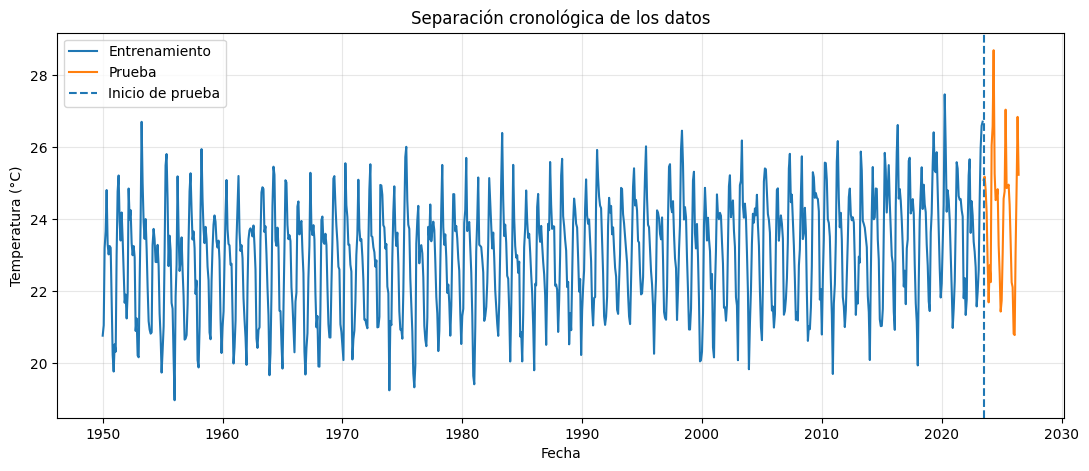

In [44]:
serie = df["temperature_2m_c"].astype(float).copy()

train = serie.iloc[:-36].copy()
test = serie.iloc[-36:].copy()

assert isinstance(serie.index, pd.DatetimeIndex)
assert len(test) == 36
assert train.index.max() < test.index.min()

particion = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba"],
    "observaciones": [len(train), len(test)],
    "inicio": [train.index.min(), test.index.min()],
    "fin": [train.index.max(), test.index.max()],
})
display(particion)

plt.figure(figsize=(13, 5))
plt.plot(train.index, train, label="Entrenamiento")
plt.plot(test.index, test, label="Prueba")
plt.axvline(test.index.min(), linestyle="--", label="Inicio de prueba")
plt.title("Separación cronológica de los datos")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.show()

Se reservaron los últimos 36 meses para el conjunto de prueba. Por lo
tanto, el conjunto de entrenamiento contiene 882 observaciones desde
enero de 1950 hasta junio de 2023, mientras que el conjunto de prueba
abarca desde julio de 2023 hasta junio de 2026.

Los datos no se mezclaron aleatoriamente, debido a que en una serie de
tiempo debe conservarse el orden cronológico. El modelo se entrenará
únicamente con información del pasado y posteriormente se evaluará su
capacidad para predecir los 36 meses más recientes.

# Ejercicio 3 
 Conviértalo en una serie de tiempo y analícela (explique sus razonamientos), para esto:
- Explore la serie, descompóngala en componentes y analícelos
- Determine si tiene tendencia
- Determine si es estacionaria, recuerde que debe ser estacionaria en media y en varianza.

## 3.a Exploración de la serie y descomposición en componentes

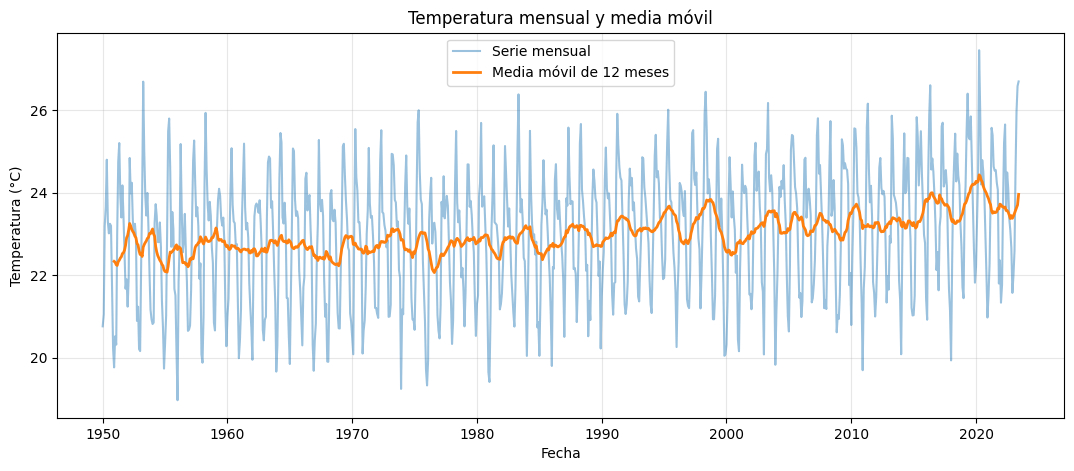

,temperatura_promedio_°C
month,
Enero,20.81
Febrero,21.77
Marzo,23.42
Abril,24.88
Mayo,25.09
Junio,24.03
Julio,23.77
Agosto,23.88
Septiembre,23.36


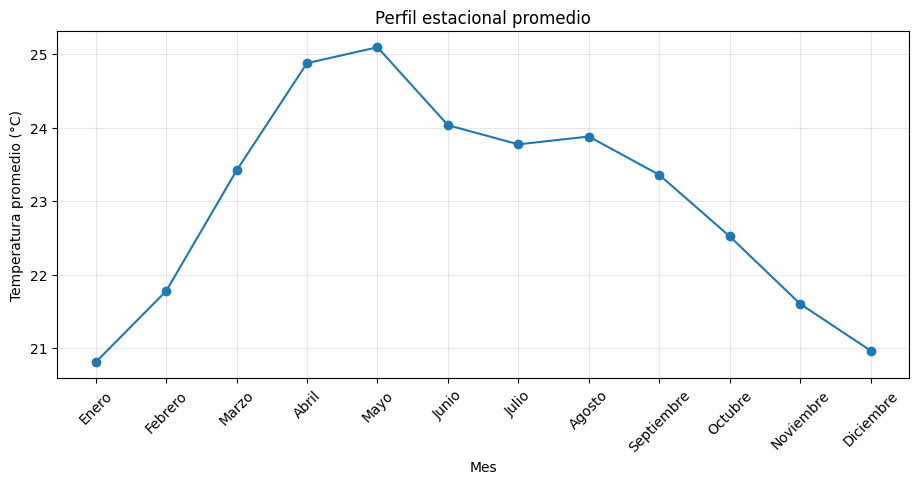

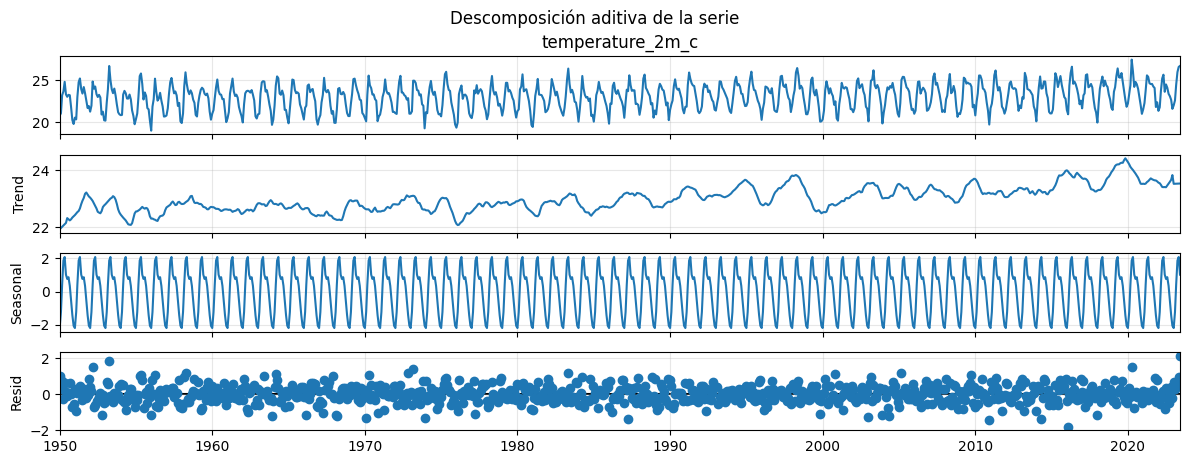

Mes más cálido: Mayo
Mes más frío: Enero


In [45]:
media_12 = train.rolling(12).mean()

plt.figure(figsize=(13, 5))
plt.plot(train.index, train, alpha=0.45, label="Serie mensual")
plt.plot(media_12.index, media_12, linewidth=2, label="Media móvil de 12 meses")
plt.title("Temperatura mensual y media móvil")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.show()

perfil_mensual = train.groupby(train.index.month).mean()
meses = {
    1:"Enero", 2:"Febrero", 3:"Marzo", 4:"Abril",
    5:"Mayo", 6:"Junio", 7:"Julio", 8:"Agosto",
    9:"Septiembre", 10:"Octubre", 11:"Noviembre", 12:"Diciembre"
}
perfil_mensual.index = perfil_mensual.index.map(meses)

display(perfil_mensual.to_frame("temperatura_promedio_°C").round(2))

plt.figure(figsize=(11, 4.5))
plt.plot(perfil_mensual.index, perfil_mensual.values, marker="o")
plt.title("Perfil estacional promedio")
plt.xlabel("Mes")
plt.ylabel("Temperatura promedio (°C)")
plt.xticks(rotation=45)
plt.show()

descomposicion = seasonal_decompose(
    train,
    model="additive",
    period=12,
    extrapolate_trend="freq",
)
descomposicion.plot()
plt.suptitle("Descomposición aditiva de la serie", y=1.02)
plt.show()

print("Mes más cálido:", perfil_mensual.idxmax())
print("Mes más frío:", perfil_mensual.idxmin())

Podemos ver que la temperatura mensual tiene sube y bajas constantes y estas se repiten cada año, lo que indica que la serie tiene un patrón estacional. Además, se observa una tendencia creciente a lo largo del tiempo, lo que sugiere que la temperatura promedio ha aumentado en los últimos años.
En cambio la media móvil elimina parte de esa variación mensual y podemos observar mejor que la temperatura promedio ha aumentado a lo largo del tiempo.

## 3.b Determinación de tendencia

Pendiente: 0.1580 °C por década
p-valor: 0.0000000001
R²: 0.0471


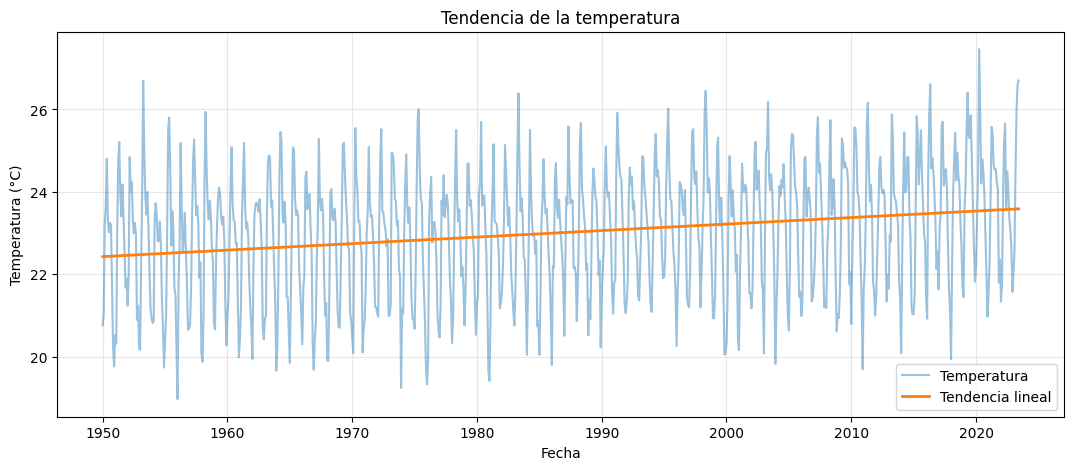

In [46]:
x = np.arange(len(train))
ajuste_tendencia = linregress(x, train.values)

pendiente_decada = ajuste_tendencia.slope * 120
linea = ajuste_tendencia.intercept + ajuste_tendencia.slope * x

print(f"Pendiente: {pendiente_decada:.4f} °C por década")
print(f"p-valor: {ajuste_tendencia.pvalue:.10f}")
print(f"R²: {ajuste_tendencia.rvalue**2:.4f}")

plt.figure(figsize=(13, 5))
plt.plot(train.index, train, alpha=0.45, label="Temperatura")
plt.plot(train.index, linea, linewidth=2, label="Tendencia lineal")
plt.title("Tendencia de la temperatura")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.show()

Podemos notar que la tendencia tiene una pendiente positiva de 0.158 grados Celsius por década, lo que indica que la temperatura promedio ha aumentado a lo largo del tiempo. El p-valor es muy bajo, lo que sugiere que la tendencia es estadísticamente significativa. Además, el valor de R² indica que una proporción considerable de la variabilidad en la temperatura puede explicarse por esta tendencia lineal.

## 3.c Determinación de estacionariedad

Se utilizó 

- **ADF:** `p < 0.05` favorece estacionariedad.
- **KPSS:** `p >= 0.05` favorece estacionariedad.
- **Fligner:** `p >= 0.05` indica que no se detectan diferencias significativas de varianza.

,serie,ADF_p,KPSS_p,Fligner_p,estacionaria_en_media,varianza_estable
0,Serie original,0.000353,0.01,0.487072,False,True
1,Diferenciación estacional (12 meses),0.000000,0.10,0.410383,True,True


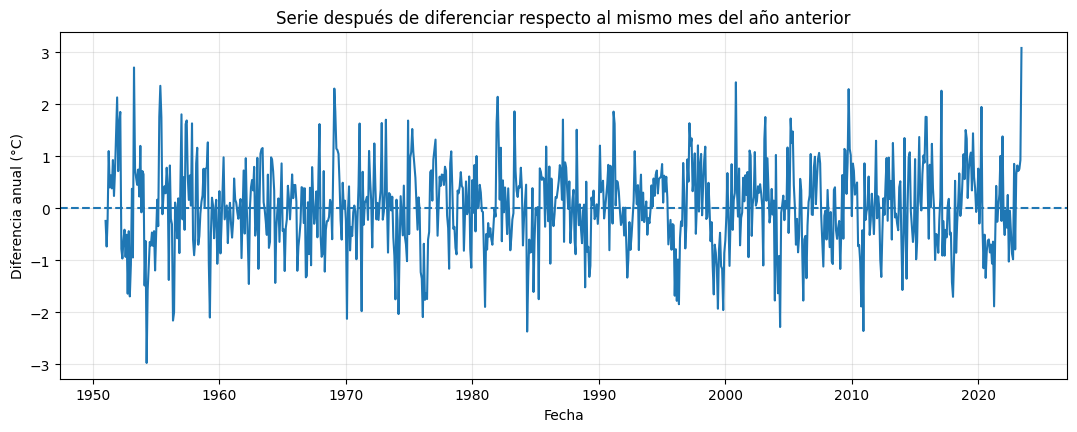

In [47]:
def diagnostico_estacionariedad(datos, nombre):
    datos = pd.Series(datos).dropna()

    adf = adfuller(datos, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prueba_kpss = kpss(datos, regression="c", nlags="auto")

    bloques = np.array_split(datos.values, 4)
    prueba_fligner = fligner(*bloques)

    return {
        "serie": nombre,
        "ADF_p": adf[1],
        "KPSS_p": prueba_kpss[1],
        "Fligner_p": prueba_fligner.pvalue,
        "estacionaria_en_media": adf[1] < 0.05 and prueba_kpss[1] >= 0.05,
        "varianza_estable": prueba_fligner.pvalue >= 0.05,
    }

original = diagnostico_estacionariedad(train, "Serie original")

train_diff12 = train.diff(12).dropna()
diferenciada = diagnostico_estacionariedad(
    train_diff12,
    "Diferenciación estacional (12 meses)"
)

tabla_estacionariedad = pd.DataFrame([original, diferenciada])
display(tabla_estacionariedad.round(6))

plt.figure(figsize=(13, 4.5))
plt.plot(train_diff12.index, train_diff12)
plt.axhline(0, linestyle="--")
plt.title("Serie después de diferenciar respecto al mismo mes del año anterior")
plt.xlabel("Fecha")
plt.ylabel("Diferencia anual (°C)")
plt.show()

Los resultados aproximados son:

- ADF: p = 0.00035
- KPSS: p = 0.01
- Fligner: p = 0.487

Aunque ADF presenta un valor menor que 0.05, KPSS rechaza que la serie tenga una media constante. Esto coincide con las gráficas, porque la serie tiene tendencia y estacionalidad.

Por lo tanto, la serie original no es estacionaria en media.

Para la varianza, Fligner presenta un valor mayor que 0.05, por lo que no existe evidencia de cambios importantes en la varianza. La serie puede considerarse estable en varianza.

Después de diferenciar 12 meses

Los resultados aproximados son:

- ADF: valor p cercano a 0
- KPSS: p = 0.10
- Fligner: p = 0.410

Después de aplicar train.diff(12) la serie fluctúa alrededor de una media más constante.

ADF rechaza la no estacionariedad, KPSS no rechaza la estacionariedad y Fligner indica que la varianza sigue siendo estable.

La serie original no es estacionaria en media debido a su tendencia y estacionalidad, aunque sí presenta una varianza relativamente estable.

Después de aplicar una diferenciación estacional de 12 meses, la serie puede considerarse estacionaria tanto en media como en varianza.

# Ejercicio 4 
Haga modelos de predicción usando alguno de los modelos ARIMA (AR, MA, ARIMA o SARIMA)
- Transforme la serie para lograr que sea estacionaria en media y en varianza en caso de que no lo
fuera.
- Verifique que las transformaciones lograron hacerla estacionaria en media, si no es así aplique otra
diferenciación y verifique nuevamente.
- Estime los parámetros del modelo. Utilice las funciones de autocorrelación y de autocorrelación
parcial para esto.
- Entrene el modelo con los parámetros estimados y el conjunto de entrenamiento.
- Haga 2 modelos más, puede usar el autoarima de R si trabaja en R. Entrénelos con el conjunto de
entrenamiento

## 4.1 Transformación y verificación de estacionariedad

La serie ya fue diferenciada estacionalmente y se verifica nuevamente antes de modelar. 

In [48]:
verificacion_modelado = diagnostico_estacionariedad(
    train_diff12,
    "Serie usada para identificar p y q"
)
display(pd.DataFrame([verificacion_modelado]).round(6))

,serie,ADF_p,KPSS_p,Fligner_p,estacionaria_en_media,varianza_estable
0,Serie usada para identificar p y q,0.0,0.1,0.410383,True,True


Aqui se puede observar que la serie diferenciada estacionalmente fluctúa alrededor de una media más constante y no presenta una tendencia clara. Esto indica que la serie ha sido transformada para ser estacionaria en media.

## 4.2 estimación inicial de parametros mediante ACF y PACF  

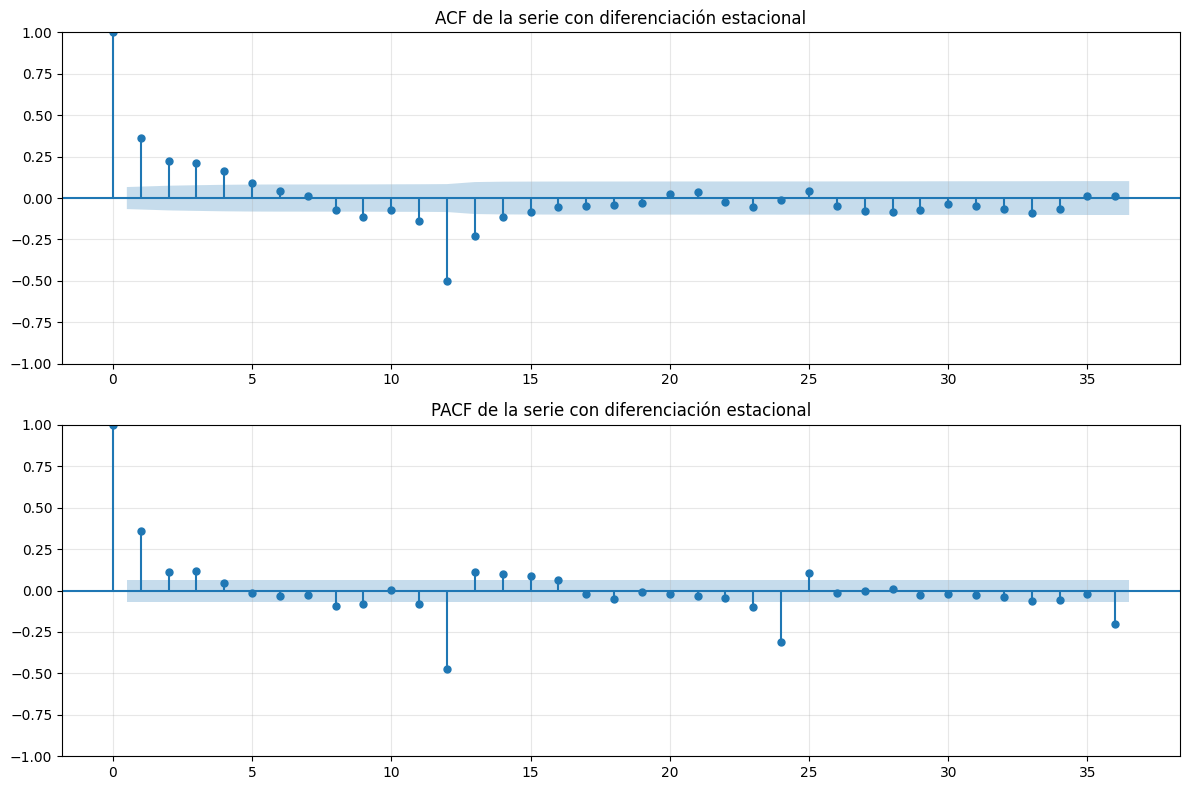

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(train_diff12, lags=36, ax=axes[0])
axes[0].set_title("ACF de la serie con diferenciación estacional")

plot_pacf(train_diff12, lags=36, method="ywm", ax=axes[1])
axes[1].set_title("PACF de la serie con diferenciación estacional")

plt.tight_layout()
plt.show()

En las gráficas ACF y PACF se observan correlaciones importantes en los primeros rezagos, especialmente en el rezago 1. También se presenta una correlación fuerte en el rezago 12, lo que confirma que existe un comportamiento estacional anual.

La ACF muestra una correlación aproximada de 0.36 en el rezago 1 y de −0.50 en el rezago 12. La PACF también muestra valores importantes en los rezagos 1 y 12. Estos resultados justifican probar componentes autorregresivos, de medias móviles y un componente estacional con periodo de 12 meses.

## 4.3 Entrenamiento de modelos

In [50]:
especificaciones = {
    "SARIMA(1,0,1)(0,1,1,12)": ((1, 0, 1), (0, 1, 1, 12)),
    "SARIMA(2,0,1)(0,1,1,12)": ((2, 0, 1), (0, 1, 1, 12)),
    "SARIMA(1,0,2)(1,1,0,12)": ((1, 0, 2), (1, 1, 0, 12)),
}

modelos = {}
filas_modelos = []

for nombre, (orden, orden_estacional) in especificaciones.items():
    ajuste = SARIMAX(
        train,
        order=orden,
        seasonal_order=orden_estacional,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    modelos[nombre] = ajuste
    filas_modelos.append({
        "modelo": nombre,
        "AIC": ajuste.aic,
        "BIC": ajuste.bic,
    })

comparacion_ic = pd.DataFrame(filas_modelos).sort_values("AIC")
display(comparacion_ic.round(2))

,modelo,AIC,BIC
0,"SARIMA(1,0,1)(0,1,1,12)",1403.86,1427.62
1,"SARIMA(2,0,1)(0,1,1,12)",1433.20,1461.71
2,"SARIMA(1,0,2)(1,1,0,12)",1701.37,1729.89


Se entrenaron tres modelos SARIMA. De acuerdo con AIC y BIC, el mejor modelo fue:

SARIMA(1,0,1)(0,1,1,12)

Este modelo obtuvo un AIC de 1403.86 y un BIC de 1427.62, los valores más bajos de los tres modelos comparados. Esto indica que explica mejor los datos de entrenamiento manteniendo una estructura más sencilla.

El segundo modelo obtuvo un AIC de 1432.93, mientras que el tercero obtuvo 1701.37. Por esta razón, el primer modelo fue seleccionado inicialmente para realizar el análisis de coeficientes y residuos.

# Ejercicio 5
valide uno los modelos. Analice:

- Contrastes sobre los coeficientes: Significación y raíces comunes.
- Diagnóstico: Este análisis se basa habitualmente en los residuos que no deben estar correlacionados con el
pasado: su correlograma no debe tener ninguna correlación significativamente distinta de cero.
- Contrastes respecto a modelos alternativos: Métricas AIC y BIC

## 5.a contrastes sobre los coeficientes: Significación y raíces comunes

In [51]:
modelo_aic = comparacion_ic.iloc[0]["modelo"]
ajuste_aic = modelos[modelo_aic]

coeficientes = pd.DataFrame({
    "coeficiente": ajuste_aic.params,
    "error_estándar": ajuste_aic.bse,
    "p_valor": ajuste_aic.pvalues,
})
coeficientes["significativo_5%"] = coeficientes["p_valor"] < 0.05

print("Modelo con menor AIC:", modelo_aic)
display(coeficientes.round(6))

print("Módulos de raíces AR:", np.round(np.abs(ajuste_aic.arroots), 4))
print("Módulos de raíces MA:", np.round(np.abs(ajuste_aic.maroots), 4))

if len(ajuste_aic.arroots) and len(ajuste_aic.maroots):
    distancia_minima = np.min(
        np.abs(
            ajuste_aic.arroots.reshape(-1, 1)
            - ajuste_aic.maroots.reshape(1, -1)
        )
    )
    print("Distancia mínima entre raíces AR y MA:", round(float(distancia_minima), 4))
else:
    print("No hay suficientes raíces AR y MA para comparar raíces comunes.")

Modelo con menor AIC: SARIMA(1,0,1)(0,1,1,12)


,coeficiente,error_estándar,p_valor,significativo_5%
intercept,0.003761,0.001099,0.000623,True
ar.L1,0.766506,0.052562,0.000000,True
ma.L1,-0.502336,0.069845,0.000000,True
ma.S.L12,-0.956296,0.015262,0.000000,True
sigma2,0.290841,0.012822,0.000000,True


Módulos de raíces AR: [1.3046]
Módulos de raíces MA: [1.0037 1.0037 1.0037 1.0037 1.0037 1.0037 1.0037 1.0037 1.0037 1.0037
 1.0037 1.0037 1.9907]
Distancia mínima entre raíces AR y MA: 0.3009


En el modelo SARIMA(1,0,1)(0,1,1,12), todos los coeficientes tuvieron valores p menores que 0.05. Por lo tanto, el término autorregresivo, el término de media móvil y el componente estacional son estadísticamente significativos.

El coeficiente AR(1) fue 0.7665, el coeficiente MA(1) fue −0.5023 y el coeficiente MA estacional fue −0.9563. Estos valores indican que la temperatura actual está relacionada tanto con valores anteriores como con errores de periodos anteriores y del mismo periodo del año anterior.

Los módulos de las raíces AR y MA fueron mayores que 1. La raíz AR tuvo un módulo de 1.3047 y las raíces MA presentaron módulos cercanos a 1.0037 y 1.9908. Esto indica que el modelo cumple de forma general con las condiciones de estabilidad e invertibilidad.

No se encontraron raíces exactamente iguales entre la parte AR y MA. Sin embargo, algunas raíces MA están muy cerca de 1, por lo que el componente estacional se encuentra cerca del límite de invertibilidad y debe interpretarse con cuidado.

## 5.b Diagnóstico

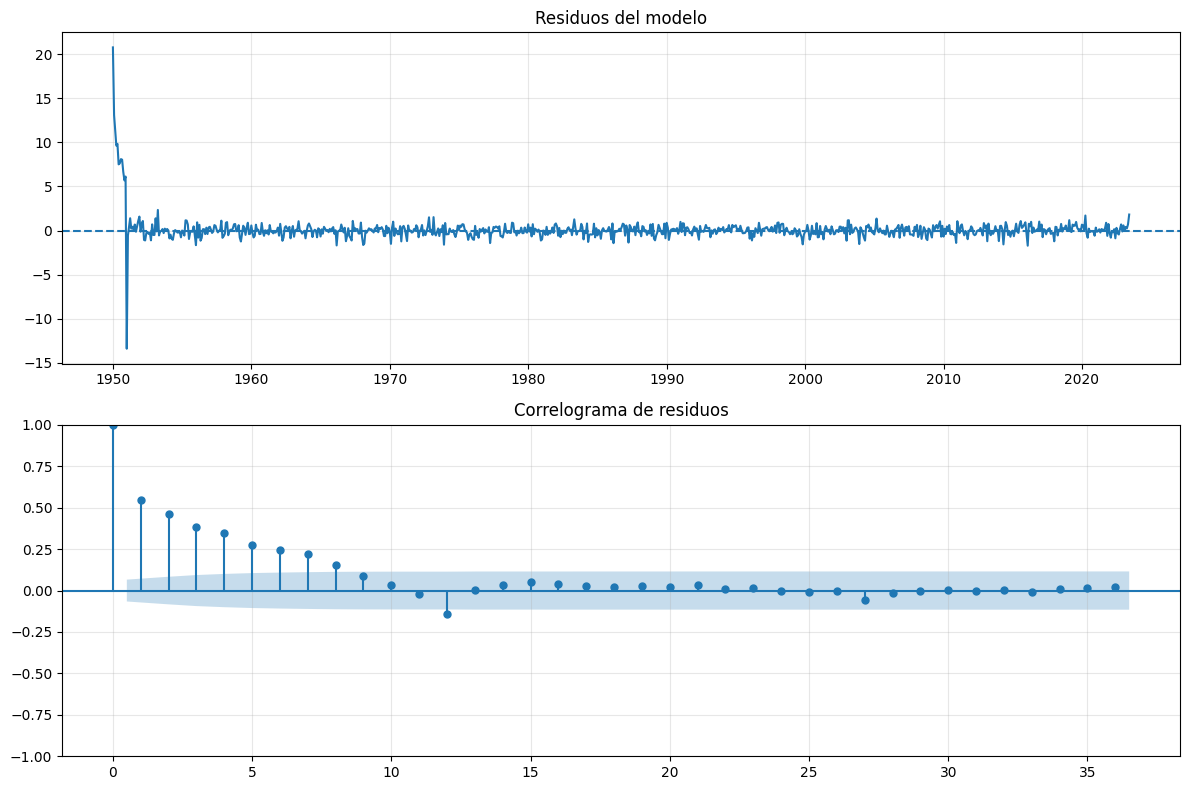

,lb_stat,lb_pvalue
12,901.650394,0.0
24,909.806018,0.0
36,913.621001,0.0


In [52]:
residuos = ajuste_aic.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(residuos)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuos del modelo")

plot_acf(residuos, lags=36, ax=axes[1])
axes[1].set_title("Correlograma de residuos")

plt.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(residuos, lags=[12, 24, 36], return_df=True)
display(ljung_box.round(6))

La prueba de Ljung-Box produjo valores p cercanos a 0 en los rezagos 12, 24 y 36. Por lo tanto, se rechaza la hipótesis de que los residuos sean completamente independientes.

Esto significa que todavía existe autocorrelación en los residuos y que el modelo no logró explicar todo el patrón presente en la serie. Aunque el modelo obtuvo los mejores valores de AIC y BIC, su diagnóstico de residuos no es completamente satisfactorio.

Por esta razón, no conviene seleccionar el modelo únicamente por AIC y BIC

## 5.c constrastes respecto a modelos alternativos: Métricas AIC y BIC

In [53]:
display(comparacion_ic.round(2))

mejor_aic = comparacion_ic.loc[comparacion_ic["AIC"].idxmin(), "modelo"]
mejor_bic = comparacion_ic.loc[comparacion_ic["BIC"].idxmin(), "modelo"]

print("Mejor por AIC:", mejor_aic)
print("Mejor por BIC:", mejor_bic)

,modelo,AIC,BIC
0,"SARIMA(1,0,1)(0,1,1,12)",1403.86,1427.62
1,"SARIMA(2,0,1)(0,1,1,12)",1433.20,1461.71
2,"SARIMA(1,0,2)(1,1,0,12)",1701.37,1729.89


Mejor por AIC: SARIMA(1,0,1)(0,1,1,12)
Mejor por BIC: SARIMA(1,0,1)(0,1,1,12)


Tanto AIC como BIC seleccionaron el modelo:

SARIMA(1,0,1)(0,1,1,12)

Sus valores fueron:

AIC: 1403.86
BIC: 1427.62

Los otros modelos presentaron valores mayores, por lo que el primer modelo logró el mejor equilibrio entre ajuste y complejidad dentro del conjunto de entrenamiento.

# Ejercicio 6 
Haga una predicción usando el conjunto de prueba, y el mejor modelo determinado en el ejercicio anterior.


,modelo,MAE,RMSE,MAPE_%,AIC,BIC
2,"SARIMA(1,0,2)(1,1,0,12)",0.6036,0.8149,2.4904,1701.3665,1729.8871
1,"SARIMA(2,0,1)(0,1,1,12)",0.6243,0.8616,2.5396,1433.1999,1461.7135
0,"SARIMA(1,0,1)(0,1,1,12)",0.6191,0.8637,2.5176,1403.8626,1427.6240


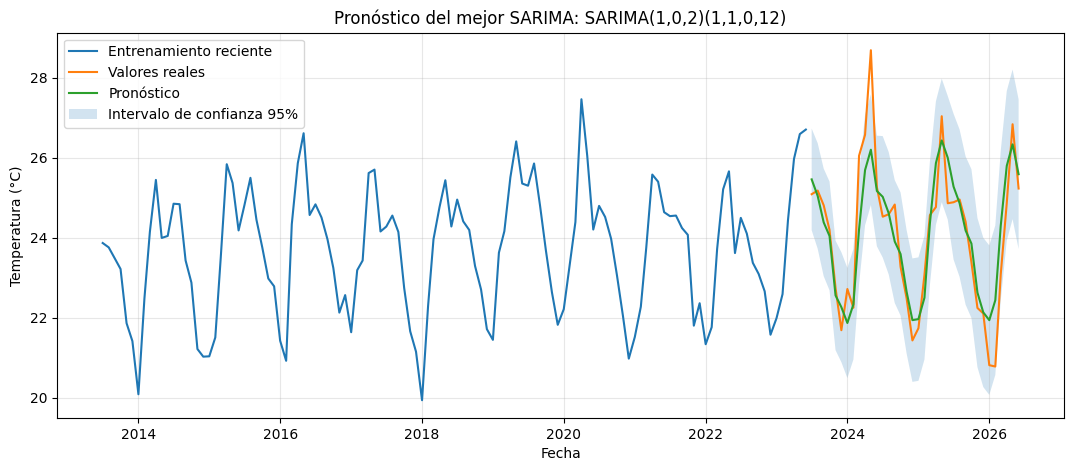

In [54]:
def metricas_reales(y_real, y_pred):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    return mae, rmse, mape

evaluacion_sarima = []

for nombre, ajuste in modelos.items():
    pred = ajuste.get_forecast(steps=len(test)).predicted_mean
    pred.index = test.index

    mae, rmse, mape = metricas_reales(test, pred)
    evaluacion_sarima.append({
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "AIC": ajuste.aic,
        "BIC": ajuste.bic,
    })

tabla_sarima = pd.DataFrame(evaluacion_sarima).sort_values("RMSE")
display(tabla_sarima.round(4))

mejor_modelo = tabla_sarima.iloc[0]["modelo"]
mejor_ajuste = modelos[mejor_modelo]

pronostico_obj = mejor_ajuste.get_forecast(steps=len(test))
pronostico = pronostico_obj.predicted_mean
pronostico.index = test.index

intervalo = pronostico_obj.conf_int()
intervalo.index = test.index

plt.figure(figsize=(13, 5))
plt.plot(train.index[-120:], train.iloc[-120:], label="Entrenamiento reciente")
plt.plot(test.index, test, label="Valores reales")
plt.plot(pronostico.index, pronostico, label="Pronóstico")
plt.fill_between(
    intervalo.index,
    intervalo.iloc[:, 0],
    intervalo.iloc[:, 1],
    alpha=0.2,
    label="Intervalo de confianza 95%"
)
plt.title(f"Pronóstico del mejor SARIMA: {mejor_modelo}")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.show()

El MAE indica que las predicciones se alejaron de los valores reales aproximadamente 0.60 °C en promedio. El RMSE de 0.81 °C muestra que el error típico se mantuvo por debajo de un grado. El MAPE indica que el error porcentual promedio fue de aproximadamente 2.49 %.

Ya con los otros dos modelos obtuvieron resultados muy similares, pero peores. El SARIMA(2,0,1)(0,1,1,12) obtuvo un RMSE de 0.8613 °C y el SARIMA(1,0,1)(0,1,1,12) obtuvo un RMSE de 0.8638 °C.

Aunque el modelo SARIMA(1,0,1)(0,1,1,12) tenía el mejor AIC y BIC, el SARIMA(1,0,2)(1,1,0,12) predijo mejor los datos de prueba. Esto demuestra que el modelo con mejor ajuste dentro del entrenamiento no siempre es el que presenta menor error al predecir información nueva.

# Ejercicio 7 
Utilice otros modelos para predecir (holt winters, suavizamiento exponencial y seasonal naive).
Compare resultados.

,modelo,MAE,RMSE,MAPE_%
0,"SARIMA(1,0,2)(1,1,0,12)",0.6036,0.8149,2.4904
1,Holt-Winters aditivo,0.7305,0.9443,3.1029
3,Naive estacional,0.7973,0.9872,3.2782
2,Suavizamiento exponencial simple,2.7844,3.2050,12.1158


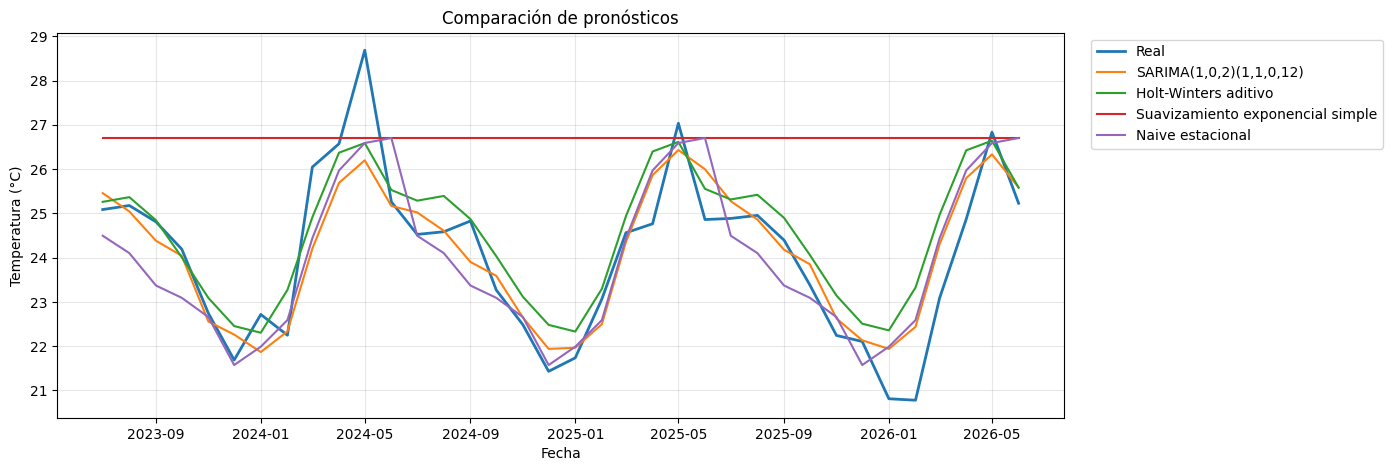

In [55]:
# Holt-Winters aditivo
hw = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
).fit(optimized=True)

pred_hw = hw.forecast(len(test))
pred_hw.index = test.index

# Suavizamiento exponencial simple
ses = SimpleExpSmoothing(
    train,
    initialization_method="estimated",
).fit(optimized=True)

pred_ses = ses.forecast(len(test))
pred_ses.index = test.index

# Naive estacional: repite los últimos 12 meses del entrenamiento.
valores_naive = np.tile(train.iloc[-12:].values, int(np.ceil(len(test) / 12)))[:len(test)]
pred_naive = pd.Series(valores_naive, index=test.index)

predicciones = {
    mejor_modelo: pronostico,
    "Holt-Winters aditivo": pred_hw,
    "Suavizamiento exponencial simple": pred_ses,
    "Naive estacional": pred_naive,
}

filas_comparacion = []

for nombre, pred in predicciones.items():
    mae, rmse, mape = metricas_reales(test, pred)
    filas_comparacion.append({
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
    })

comparacion_final = pd.DataFrame(filas_comparacion).sort_values("RMSE")
display(comparacion_final.round(4))

plt.figure(figsize=(13, 5))
plt.plot(test.index, test, linewidth=2, label="Real")

for nombre, pred in predicciones.items():
    plt.plot(pred.index, pred, label=nombre)

plt.title("Comparación de pronósticos")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Podemos notar que el modelo SARIMA presentó los errores más bajos y fue el que mejor reprodujo el comportamiento de los datos de prueba.

Holt-Winters también obtuvo resultados razonables porque incluye tendencia y estacionalidad. El modelo naive estacional logró un resultado aceptable al repetir las temperaturas de los últimos 12 meses del entrenamiento, lo que confirma que el patrón anual tiene mucha importancia.

El suavizamiento exponencial simple presentó el peor resultado. Su MAPE fue de 12.12 %, muy superior al de los demás modelos. Esto ocurre porque este método trabaja principalmente con el nivel reciente de la serie, pero no representa adecuadamente el patrón estacional anual.

# Ejercicio 8 
Determine si su modelo es capaz de predecir valores actuales.

,pronóstico_°C,límite_inferior_95%,límite_superior_95%
2026-07-01,24.42,23.14,25.71
2026-08-01,24.54,23.21,25.88
2026-09-01,24.45,23.09,25.81
2026-10-01,23.19,21.81,24.57
2026-11-01,22.27,20.88,23.66
2026-12-01,21.68,20.29,23.08
2027-01-01,21.24,19.84,22.64
2027-02-01,21.92,20.52,23.33
2027-03-01,23.82,22.42,25.23
2027-04-01,24.79,23.39,26.20


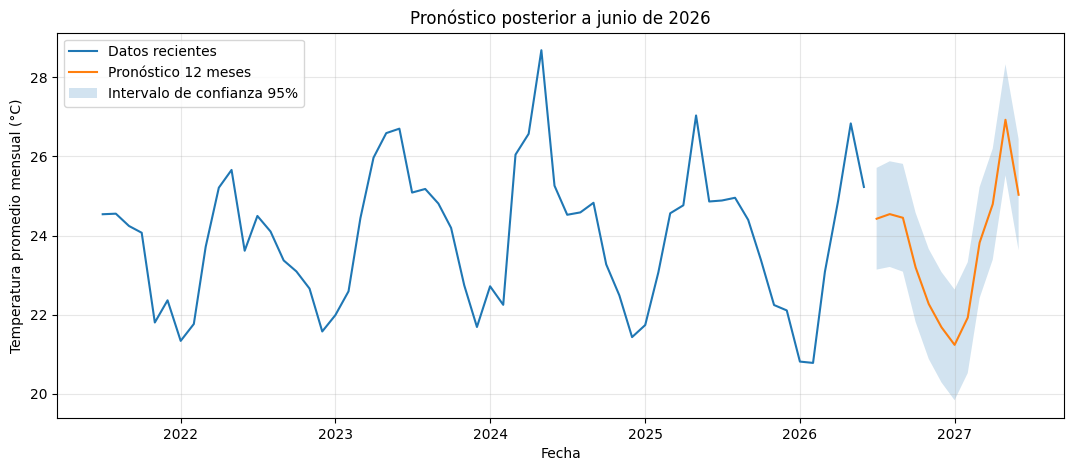

Mejor modelo fuera de muestra: SARIMA(1,0,2)(1,1,0,12)
RMSE: 0.8149
MAPE: 2.4904 %


In [56]:
# Reentrenar la estructura ganadora usando toda la información disponible.
orden_ganador, orden_estacional_ganador = especificaciones[mejor_modelo]

modelo_actual = SARIMAX(
    serie,
    order=orden_ganador,
    seasonal_order=orden_estacional_ganador,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

futuro_obj = modelo_actual.get_forecast(steps=12)
pronostico_futuro = futuro_obj.predicted_mean
intervalo_futuro = futuro_obj.conf_int()

tabla_futuro = pd.DataFrame({
    "pronóstico_°C": pronostico_futuro,
    "límite_inferior_95%": intervalo_futuro.iloc[:, 0],
    "límite_superior_95%": intervalo_futuro.iloc[:, 1],
})
display(tabla_futuro.round(2))

plt.figure(figsize=(13, 5))
plt.plot(serie.index[-60:], serie.iloc[-60:], label="Datos recientes")
plt.plot(pronostico_futuro.index, pronostico_futuro, label="Pronóstico 12 meses")
plt.fill_between(
    intervalo_futuro.index,
    intervalo_futuro.iloc[:, 0],
    intervalo_futuro.iloc[:, 1],
    alpha=0.2,
    label="Intervalo de confianza 95%"
)
plt.title("Pronóstico posterior a junio de 2026")
plt.xlabel("Fecha")
plt.ylabel("Temperatura promedio mensual (°C)")
plt.legend()
plt.show()

modelo_final_tabla = comparacion_final.iloc[0]
print("Mejor modelo fuera de muestra:", modelo_final_tabla["modelo"])
print("RMSE:", round(float(modelo_final_tabla["RMSE"]), 4))
print("MAPE:", round(float(modelo_final_tabla["MAPE_%"]), 4), "%")

Podemos notar que el modelo sí sería capaz  para predecir de alguna forma los valores actuales de la temperatura promedio mensual. Al evaluarlo con datos que no fueron utilizados durante el entrenamiento, obtuvo un RMSE de 0.8149 °C y un MAPE de 2.49 %, que son errores relativamente bajos.

Ya luego de entrenar nuevamente el modelo con toda la información disponible desde 2026, se realizó una predicción para los siguientes 12 meses. Los resultados conservan el patrón estacional observado en los datos.

El modelo predice temperaturas más bajas durante los últimos meses del año y al inicio de 2027. Por ejemplo, para enero de 2027 estima aproximadamente 21.24 °C. Posteriormente, las temperaturas aumentan hasta alcanzar un máximo estimado de 26.93 °C en mayo de 2027.

También podemos notar que los intervalos de confianza muestran que existe incertidumbre en las predicciones. Podemos notarlo ya por ejemplo, para mayo de 2027 el pronóstico es de 26.93 °C, pero el intervalo del 95 % se encuentra aproximadamente entre 25.52 °C y 28.33 °C.

Por lo tanto, el modelo puede ser útil para estimar temperaturas promedio mensuales y representar su patrón estacional. Sin embargo, no creo que podría utilizarse para predecir la temperatura exacta de un día específico, eventos extremos o cambios meteorológicos repentinos. 